### Tables of units and blades' map.

In [5]:
AMPSUB = {
    0    : 1.0,    # no unit defined.
    "mA" : 1e-3,   # mili
    "uA" : 1e-6,   # micro
    "nA" : 1e-9,   # nano
    "pA" : 1e-12,  # pico
    "fA" : 1e-15,  # femto
    "aA" : 1e-18,  # atto
}

# The XBPM beamlines.
BEAMLINENAME = {
    "CAT": "Cateretê",
    "CNB": "Carnaúba",
    "MGN": "Mogno",
    "MNC": "Manacá",
}

BLADEMAP = {
    "MNC": {"TO": 'C', "TI": 'A', "BI": 'D', "BO": 'B'},
    "MNC1": {"TO": 'C', "TI": 'A', "BI": 'D', "BO": 'B'},
    "MNC2": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    "CAT":  {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    # "CAT1": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},

    # ## To be checked: ## #
    # "CAT2": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    "CNB": {"TO": 'C', "TI": 'A', "BI": 'D', "BO": 'B'},
    # "CNB1": {"TO": 'C', "TI": 'A', "BI": 'D', "BO": 'B'},
    # "CNB2": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    "MGN": {"TO": 'C', "TI": 'A', "BI": 'D', "BO": 'B'},
    "MGN1": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    "MGN2": {"TO": 'B', "TI": 'A', "BI": 'C', "BO": 'D'},
    "SIM":  {"TO": 'A', "TI": 'B', "BI": 'C', "BO": 'D'},
}

FILE_EXTENSION = ".pickle"    # Data file type.

### Procedures for 2025-06-11

#### Set of functions to read data from files and restructure them for each beamline, in columns for each blade's value, the undulator gap and the SR current.

In [4]:
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle  # noqa: S403


In [89]:
def data_from_file(wdir):
    """Read data from pickle files."""
    allfiles = os.listdir(wdir)
    picklefiles = [pf for pf in allfiles if pf.endswith("pickle")]
    sfiles = sorted(picklefiles, key=lambda name: lastfield(name, '_'))

    rawdata = list()
    for file in sfiles:
        with open(wdir + "/" + file, 'rb') as df:
            rawdata.append(pickle.load(df))  # noqa: S301

    return rawdata


def lastfield(name, fld=' '):  # noqa: D103
    return name.split(fld)[-1]


def read_rawdata(rawdata):
    """."""
    data = dict()
    blk = 0
    for nline in range(6):
        beamline = rawdata[blk][0][nline]['name']
        data[beamline] = dict()

    for blk in range(len(rawdata)):
        for nline, bline in enumerate(data.keys()):
            data[bline][blk] = dict()
            # For each block.
            data[bline][blk]['data'] = deepcopy(rawdata[blk][0][nline])
            data[bline][blk]['info'] = deepcopy(rawdata[blk][1])

    return data


def data_structure_average(rdata):
    """Average over blades' values and simplify data structure."""
    data = dict()
    for bline in rdata.keys():
        for blk in range(len(rdata[bline].keys())):
            for bld in ["A", "B", "C", "D"]:
                blade = f"{bld}_val"
                av = average_blade(rdata[bline][blk]['data'][blade])
                rdata[bline][blk]['data'][blade] = av
                del rdata[bline][blk]['data'][f"{bld}_range"]
            del rdata[bline][blk]['data']["name"]
            del rdata[bline][blk]['data']["prefix"]

            rdata[bline][blk]['data']["current"] = rdata[bline][blk]['info']["current"]
            del rdata[bline][blk]['info']["current"]

            bl = bline[:3].lower()
            # print(f"BL = {bl}")
            if bl in rdata[bline][blk]['info'].keys():
                rdata[bline][blk]['data']['gap'] = rdata[bline][blk]['info'][bl]

            del rdata[bline][blk]["info"]
            rdata[bline][blk] = rdata[bline][blk]["data"]

        dt = dict()
        for key, rd in rdata[bline].items():
            dt[key] = rd
        data[bline] = dt
    return data


def average_blade(blade):
    """Function for averaging over each blade's measurement."""
    bld = []
    for val in blade:
        bld.append(val[0] * AMPSUB[val[1]])
    return np.array([np.average(bld), np.std(bld)])


def pandas_data_frame(data):
    """Data to pandas' data frame."""
    pdata = dict()
    for key, val in data.items():
        pdata[key] = pd.DataFrame(val)
    return pdata


def blades_data_array(pdata, beamline):
    """Divide data into arrays for each blade."""
    blades = {
        "A_val" : [],
        "B_val" : [],
        "C_val" : [],
        "D_val" : [],
    }

    for ip, p in enumerate(pdata[beamline]):
        crr = np.round(pdata[beamline][p]["current"], decimals=-1)

        try:
            gap = np.round(pdata[beamline][p]["gap"], decimals=0)
        except Exception as err:
            print(f" WARNING: beamline {beamline}, data # {ip}:"
                  f"\t Exception when trying to define {err}")
            gap = None

        # print(f">>> (BLADES DATA RRAY) gap {beamline} = {gap}")

        for bl in blades.keys():
            blval = pdata[beamline][p][bl]
            # print(f" {cr} ({type(cr)}) : {bl} → {blval}")
            blades[bl].append([crr, gap, blval[0], blval[1]])

    for key, val in blades.items():
        blades[key] = np.array(val)

    return blades


def blades_plot(blades, beamline):
    """Plot data."""
    for key, val in blades.items():

        # print(f"\n>>>> key = {key} : \n {val[:, 0]} {val[:, 2]} \n")
        mask = val[:, 2] >= -5e-12
        x = val[:, 0]
        y = val[:, 2]
        s = val[:, 3]

        # print(f">>> (BLADES PLOT) {key} : \n {val} ")

        plt.errorbar(x[mask], y[mask], s[mask], label=key)




## Main.

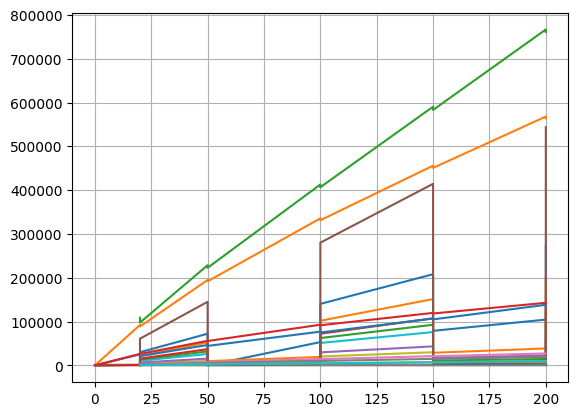

In [90]:

def main(wdir):

    # List with data read from working directory.
    rawdata = data_from_file(basedir + wdir)

    # Extract data from read files and compose a dict relative to each beam line.
    rdata   = read_rawdata(rawdata)

    # Average over blades' measurements and simplify data structure dictionary.
    data    = data_structure_average(rdata)

    # Export data to a pandas data frame.
    pdata   = pandas_data_frame(data)

    # for k in pdata["CAT"][0].keys():
    #     print(f"##### PDATA: \n{k} : {pdata['CAT'][0][k]}")

    for beamline in pdata.keys():
        blades = blades_data_array(pdata, beamline=beamline)

        # print(f">>> (MAIN) BLADES KEYS: {beamline} = \n {blades.keys()}")

        blades_plot(blades, f"XBPM Blades' measurement @ {beamline}")

        # print(f">>> (MAIN) BLADES: {beamline} ")

    # beamline = "CNB"
    # blades = blades_data_array(pdata, beamline=beamline)
    # blades_plot(blades, f"XBPM Blades' measurement @ {beamline}")

    # plt.legend()
    plt.grid()
    plt.show()


# basedir = "/home/arnaldo.filho/XBPM/medidas/results_2025/"
basedir = "/home/agolivei/CNPEM/XBPM/medidas/results_2025/"
# wdir = "MNC_1_20250729/subsec_09SA"
# wdir = "MNC_1_20250623/2025-06-23"
wdir = "Gaps_20250616/2025-06-16"


if __name__ == "__main__":
    main(wdir)

In [ ]:
wdir = "/home/agolivei/CNPEM/XBPM/medidas/results_2025/Gaps_20250616/2025-06-16"

rawdata = data_from_file(wdir)

# print(f"\n KEYS = {rawdata[0][0][0].keys()} \n")

# Check info.
# for ii in range(19):
#     for rd in rawdata[ii][1]:
#         # print(f"({rd['name']:5}) {rd.keys()}")
#         print(f"{rd} = {rawdata[ii][1][rd]:14.4f}", end="\t")
#     print()

# Check data keys.
# for ii in range(19):
#     for rd in rawdata[ii][0]:
#         print(f"{rd.keys()}")
#     print()

rdata = read_rawdata(rawdata)
rdata['CNB'][0]['data']["C_val"]
